# From Pilot to Payoff - 05: Q4 - Business Payoff and Digital-Maturity Moderation

Q4: Is advanced adoption associated with business payoff, and does payoff differ by national digital maturity?


### Q4 - Business Payoff and Digital-Maturity Moderation

This section combines Session 5/6 group comparison tests with Session 7 regression. Because the sample is large, we report adjusted R2 and compare each model's contribution rather than relying on p-values alone.


## Setup and data preparation

Re-runs the shared imports, data loading, feature engineering, and standardisation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.formula.api import ols

import matplotlib.pyplot as plt

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transform for the skewed investment variable.
# 780 firms (0.52%) report zero AI investment; np.log1p collapses these to 0, far below the
# positive mass (median log ~10.7), creating an artificial left-skewed spike (skew -2.8) that
# distorts the standardised predictor feeding the Q3 logistic model. Instead, log the positive
# amounts (near-symmetric, skew -0.43) and set the rare zeros to the median log, so they sit at
# the centre rather than forming a distorting tail.
_pos_investment = company['ai_investment_per_employee'] > 0
_log_investment = np.log(company['ai_investment_per_employee'].where(_pos_investment))
company['log_ai_investment_per_employee'] = _log_investment.fillna(_log_investment.median())

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 58 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']

In [6]:
# Group comparison of each business outcome by adoption maturity.
# Kruskal-Wallis across the four stages, and Mann-Whitney U (advanced vs non-advanced).
# H0: no difference in distribution between groups.  H1: a difference exists.  alpha = 0.05.
business_outcomes = {
    'productivity_change_percent': 'Productivity change (%)',
    'revenue_growth_percent': 'Revenue growth (%)',
    'cost_reduction_percent': 'Cost reduction (%)',
    'innovation_score': 'Innovation score',
    'customer_satisfaction': 'Customer satisfaction'
}

business_test_rows = []
for col, label in business_outcomes.items():
    stage_groups = [df.loc[df['ai_adoption_stage'] == stage, col].dropna() for stage in stage_order]
    h_stat, kw_p = stats.kruskal(*stage_groups)
    adv = df.loc[df['advanced_adoption'] == 1, col]
    nonadv = df.loc[df['advanced_adoption'] == 0, col]
    u_stat, mw_p = stats.mannwhitneyu(adv, nonadv, alternative='two-sided')
    business_test_rows.append({
        'outcome': label,
        'advanced_mean': adv.mean(),
        'non_advanced_mean': nonadv.mean(),
        'mean_difference': adv.mean() - nonadv.mean(),
        'kruskal_p_value': kw_p,
        'mann_whitney_p_value': mw_p
    })

business_tests = pd.DataFrame(business_test_rows)
business_tests


,outcome,advanced_mean,non_advanced_mean,mean_difference,kruskal_p_value,mann_whitney_p_value
0,Productivity change (%),12.189183,5.883665,6.305518,0.0,0.0
1,Revenue growth (%),6.240794,2.714272,3.526522,0.0,0.0
2,Cost reduction (%),5.829509,3.640198,2.189311,0.0,0.0
3,Innovation score,58.472995,51.410329,7.062666,0.0,0.0
4,Customer satisfaction,5.770525,5.015495,0.755031,0.0,0.0


In [7]:
# OLS outcome models. M0 controls only; M1 adds advanced adoption; M2 adds representative firm-level drivers.
ols_control_terms = 'C(country) + C(industry) + C(company_size) + C(survey_year) + C(quarter)'
representative_driver_terms = (
    'z_ai_training_hours + z_years_using_ai + z_ai_budget_percentage + '
    'z_regulatory_compliance_score + z_ai_risk_management_score'
)

business_ols_rows = []
business_ols_models = {}
for outcome, label in business_outcomes.items():
    m0 = ols(f'{outcome} ~ {ols_control_terms}', data=df).fit()
    m1 = ols(f'{outcome} ~ advanced_adoption + {ols_control_terms}', data=df).fit()
    m2 = ols(f'{outcome} ~ advanced_adoption + {representative_driver_terms} + {ols_control_terms}', data=df).fit()
    business_ols_models[outcome] = {'M0': m0, 'M1': m1, 'M2': m2}
    business_ols_rows.append({
        'outcome': label,
        'advanced_beta_M1': m1.params.get('advanced_adoption', np.nan),
        'p_value_M1': m1.pvalues.get('advanced_adoption', np.nan),
        'adj_R2_controls': m0.rsquared_adj,
        'adj_R2_plus_advanced': m1.rsquared_adj,
        'delta_adj_R2_advanced': m1.rsquared_adj - m0.rsquared_adj,
        'adj_R2_plus_drivers': m2.rsquared_adj,
        'delta_adj_R2_drivers': m2.rsquared_adj - m1.rsquared_adj
    })

business_ols_summary = pd.DataFrame(business_ols_rows)
business_ols_summary


,outcome,advanced_beta_M1,p_value_M1,adj_R2_controls,adj_R2_plus_advanced,delta_adj_R2_advanced,adj_R2_plus_drivers,delta_adj_R2_drivers
0,Productivity change (%),5.813068,0.0,0.101028,0.345503,0.244475,0.510352,0.164849
1,Revenue growth (%),3.284857,0.0,0.029415,0.117099,0.087684,0.161604,0.044505
2,Cost reduction (%),2.065253,0.0,0.026645,0.112315,0.085670,0.152173,0.039858
3,Innovation score,6.511190,0.0,0.052303,0.184283,0.131980,0.264757,0.080474
4,Customer satisfaction,0.702909,0.0,0.036968,0.140554,0.103586,0.207750,0.067196


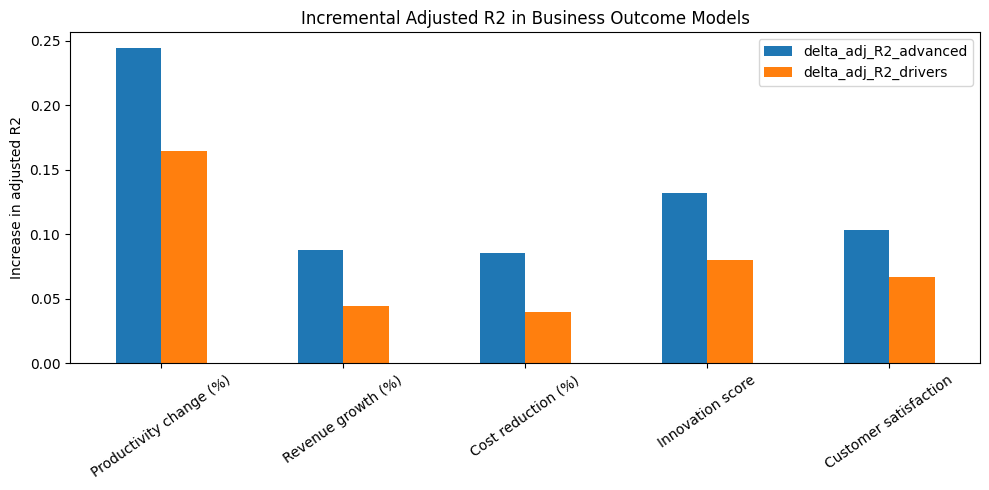

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = business_ols_summary.set_index('outcome')[['delta_adj_R2_advanced', 'delta_adj_R2_drivers']]
plot_data.plot(kind='bar', ax=ax)
ax.set_title('Incremental Adjusted R2 in Business Outcome Models')
ax.set_ylabel('Increase in adjusted R2')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_06_business_adj_r2.png', bbox_inches='tight')
plt.show()


In [9]:
# Interaction model: does the advanced-adoption payoff differ by national digital maturity?
# digital_maturity_tertile is constant within a country, so its main effect is collinear with the
# C(country) controls; we keep the controls and the interaction (which is identified, because
# advanced_adoption varies within country) and drop the redundant tertile main effect.
interaction_outcomes = ['productivity_change_percent', 'revenue_growth_percent', 'cost_reduction_percent']
interaction_rows = []
for outcome in interaction_outcomes:
    formula = (f'{outcome} ~ advanced_adoption + '
               f'advanced_adoption:C(digital_maturity_tertile) + {ols_control_terms}')
    res = ols(formula, data=df).fit()
    for term in res.params.index:
        if term == 'advanced_adoption' or term.startswith('advanced_adoption:C(digital_maturity_tertile)'):
            interaction_rows.append({
                'outcome': outcome,
                'term': term,
                'coef': res.params[term],
                'p_value': res.pvalues[term],
                'adj_R2': res.rsquared_adj
            })

interaction_summary = pd.DataFrame(interaction_rows)
interaction_summary


,outcome,term,coef,p_value,adj_R2
0,productivity_change_percent,advanced_adoption,5.727258,0.000000,0.345527
1,productivity_change_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.140414,0.013482,0.345527
2,productivity_change_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.127902,0.028876,0.345527
3,revenue_growth_percent,advanced_adoption,3.248975,0.000000,0.117100
4,revenue_growth_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.089507,0.150668,0.117100
5,revenue_growth_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.019114,0.765708,0.117100
6,cost_reduction_percent,advanced_adoption,2.067916,0.000000,0.112306
7,cost_reduction_percent,advanced_adoption:C(digital_maturity_tertile)[...,-0.016488,0.678076,0.112306
8,cost_reduction_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.009570,0.815045,0.112306


**Q4 interpretation.** Advanced adopters show higher productivity (~12% vs ~6%), revenue growth, cost reduction, innovation, and customer satisfaction. With n = 150,000 the non-parametric p-values fall below floating-point precision (they print as 0.0), so the **adjusted-R2 deltas** - not the p-values - are the meaningful evidence: advanced adoption adds the most explanatory value for productivity (delta adj R2 ~ 0.24) and progressively less for innovation, customer satisfaction, revenue, and cost.

On moderation, the corrected interaction model shows the advanced-adoption payoff is at most **marginally** larger in higher-maturity countries (interaction coefficients ~ 0.13-0.14 on a base productivity effect of ~ 5.7 points, i.e. roughly a 2% relative change, only borderline significant). We therefore conclude that national digital maturity does **not** meaningfully moderate the firm-level payoff. As in the other sections, these are associations rather than causal effects and partly reflect the simulated structure of the data.
